# Phase B Archetype Re-clustering — 2026-04-30

Three tracks: Gower+hierarchical, mixed-type GMM, supervised mood classifier. Decision rules in spec.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from IPython.display import display
import gower
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

DATA = Path('../../../data/extracted.json')
MOODS = Path('mood_labels.csv')
FIGS = Path('../figures/2026-04-30-phase-b')
FIGS.mkdir(parents=True, exist_ok=True)

CONT_VARS = ['btn_radius','card_radius','heading_weight','body_line_height',
             'heading_letter_spacing','brand_l','brand_c','brand_h','gray_chroma','accent_offset']
ORD_VARS  = ['shadow_intensity','btn_shape']
BOOL_VARS = ['is_fully_pill','dark_mode_present']
ALL_VARS  = CONT_VARS + ORD_VARS + BOOL_VARS

In [2]:
df = pd.DataFrame(json.loads(DATA.read_text()))
moods = pd.read_csv(MOODS)
df = df.merge(moods, on='system', how='left')
print(f'rows: {len(df)}; mood-labeled: {df["mood"].notna().sum()}')
print('\nFailure rate per variable:')
for v in ALL_VARS:
    null = df[v].isna().sum()
    print(f'  {v:24s} {null}/{len(df)} ({null/len(df)*100:.1f}%)')
print('\nMood distribution:')
print(df['mood'].value_counts().to_string())
print('\nis_fully_pill distribution:')
print(df['is_fully_pill'].value_counts(dropna=False).to_string())

rows: 58; mood-labeled: 58

Failure rate per variable:
  btn_radius               2/58 (3.4%)
  card_radius              20/58 (34.5%)
  heading_weight           1/58 (1.7%)
  body_line_height         2/58 (3.4%)
  heading_letter_spacing   7/58 (12.1%)
  brand_l                  1/58 (1.7%)
  brand_c                  1/58 (1.7%)
  brand_h                  1/58 (1.7%)
  gray_chroma              10/58 (17.2%)
  accent_offset            20/58 (34.5%)
  shadow_intensity         17/58 (29.3%)
  btn_shape                1/58 (1.7%)
  is_fully_pill            1/58 (1.7%)
  dark_mode_present        1/58 (1.7%)

Mood distribution:
mood
bold_energetic      17
clean_minimal       13
professional        12
playful_creative     9
warm_friendly        7

is_fully_pill distribution:
is_fully_pill
False    56
True      1
None      1


In [3]:
# Gower distance: impute NaN per column (median for continuous, mode for categorical+bool)
mixed = df[CONT_VARS + ORD_VARS + BOOL_VARS].copy()
for v in CONT_VARS:
    mixed[v] = mixed[v].astype(float).fillna(mixed[v].median())
for v in ORD_VARS:
    mixed[v] = mixed[v].astype(float).fillna(mixed[v].mode().iloc[0])
for v in BOOL_VARS:
    mixed[v] = mixed[v].astype(float).fillna(mixed[v].mode().iloc[0])
cat_mask = np.array([False]*len(CONT_VARS) + [True]*len(ORD_VARS) + [True]*len(BOOL_VARS))
gower_dist = gower.gower_matrix(mixed.to_numpy(dtype=float), cat_features=cat_mask)
print(f'Gower distance matrix: {gower_dist.shape}, NaN entries: {np.isnan(gower_dist).sum()}')

Gower distance matrix: (58, 58), NaN entries: 0


k=3 silhouette=0.132
k=4 silhouette=0.117
k=5 silhouette=0.164
k=6 silhouette=0.128
k=7 silhouette=0.123

Gower+hierarchical best: k=5, silhouette=0.164


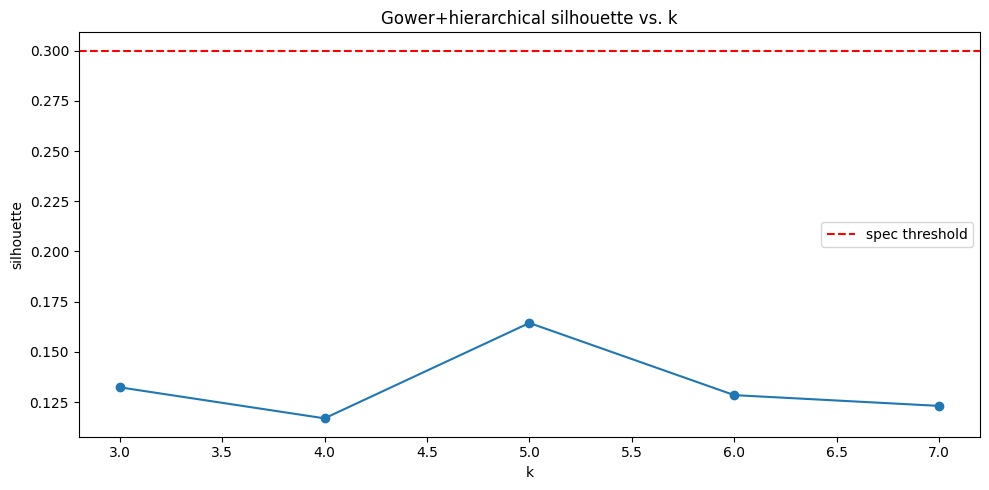

In [4]:
condensed = squareform(gower_dist, checks=False)
Z = linkage(condensed, method='average')
ks = list(range(3, 8)); sils = []
for k in ks:
    labels = fcluster(Z, t=k, criterion='maxclust')
    s = silhouette_score(gower_dist, labels, metric='precomputed')
    sils.append(s); print(f'k={k} silhouette={s:.3f}')
gower_best_k = ks[int(np.argmax(sils))]
gower_best_sil = max(sils)
print(f'\nGower+hierarchical best: k={gower_best_k}, silhouette={gower_best_sil:.3f}')
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ks, sils, 'o-')
ax.axhline(0.30, color='red', linestyle='--', label='spec threshold')
ax.set_xlabel('k'); ax.set_ylabel('silhouette'); ax.legend()
ax.set_title('Gower+hierarchical silhouette vs. k')
fig.tight_layout(); fig.savefig(FIGS / 'gower-silhouette.png', dpi=120); plt.show()

In [5]:
gower_labels = fcluster(Z, t=gower_best_k, criterion='maxclust')
df_g = df.copy(); df_g['gower_cluster'] = gower_labels
profile = df_g.groupby('gower_cluster')[CONT_VARS + ORD_VARS].mean(numeric_only=True).round(2)
display(profile)
for cid, group in df_g.groupby('gower_cluster'):
    members = ', '.join(group['system'].head(8).tolist())
    suffix = '...' if len(group) > 8 else ''
    print(f'cluster {cid} (n={len(group)}): {members}{suffix}')

,btn_radius,card_radius,heading_weight,body_line_height,heading_letter_spacing,brand_l,brand_c,brand_h,gray_chroma,accent_offset,shadow_intensity,btn_shape
gower_cluster,,,,,,,,,,,,
1,9.85,6.80,445.85,1.43,-0.87,0.54,0.18,176.26,0.02,29.07,1.82,2.08
2,16.76,2.10,520.38,1.45,-0.89,0.43,0.11,129.97,0.01,194.89,2.00,1.92
3,28.50,2.75,675.00,1.40,-0.53,0.29,0.05,236.26,0.01,322.80,4.00,2.25
4,11.23,3.46,390.46,1.39,-1.89,0.23,0.00,23.16,0.00,156.18,2.69,2.77
5,0.00,40.00,700.00,1.40,NaN,0.89,0.19,104.31,0.00,0.30,4.00,0.00


cluster 1 (n=13): cursor, kraken, lamborghini, minimax, miro, mistral.ai, nvidia, pinterest...
cluster 2 (n=27): airbnb, airtable, apple, bmw, cal, claude, clay, clickhouse...
cluster 3 (n=4): notion, posthog, raycast, sentry
cluster 4 (n=13): figma, framer, intercom, lovable, mintlify, ollama, replicate, resend...
cluster 5 (n=1): renault


In [6]:
X_cont = df[CONT_VARS].to_numpy(dtype=float)
X_cont = SimpleImputer(strategy='median').fit_transform(X_cont)
X_cont = StandardScaler().fit_transform(X_cont)
ord_arr = df[ORD_VARS].fillna(-1).to_numpy(dtype=float)
bool_arr = df[BOOL_VARS].fillna(False).astype(int).to_numpy()
X_mix = np.hstack([X_cont, ord_arr, bool_arr])
print('GMM input shape:', X_mix.shape)

GMM input shape: (58, 14)


k=3 BIC=1770 silhouette=0.096
k=4 BIC=1785 silhouette=0.096
k=5 BIC=1264 silhouette=0.087


k=6 BIC=1153 silhouette=0.081


k=7 BIC=958 silhouette=0.101

GMM best (silhouette): k=7, sil=0.101


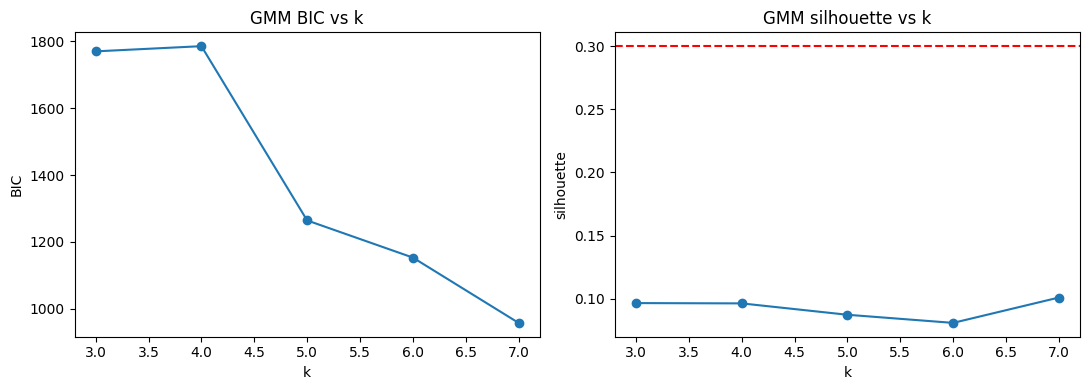

In [7]:
ks = list(range(3, 8)); bics = []; sils_g = []
for k in ks:
    gmm = GaussianMixture(n_components=k, n_init=5, random_state=42, covariance_type='full').fit(X_mix)
    bics.append(gmm.bic(X_mix))
    labels = gmm.predict(X_mix)
    sils_g.append(silhouette_score(X_mix, labels))
    print(f'k={k} BIC={bics[-1]:.0f} silhouette={sils_g[-1]:.3f}')
gmm_best_k = ks[int(np.argmax(sils_g))]
gmm_best_sil = max(sils_g)
print(f'\nGMM best (silhouette): k={gmm_best_k}, sil={gmm_best_sil:.3f}')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(ks, bics, 'o-'); ax1.set_xlabel('k'); ax1.set_ylabel('BIC'); ax1.set_title('GMM BIC vs k')
ax2.plot(ks, sils_g, 'o-'); ax2.axhline(0.30, color='red', linestyle='--')
ax2.set_xlabel('k'); ax2.set_ylabel('silhouette'); ax2.set_title('GMM silhouette vs k')
fig.tight_layout(); fig.savefig(FIGS / 'gmm-search.png', dpi=120); plt.show()

In [8]:
gmm = GaussianMixture(n_components=gmm_best_k, n_init=5, random_state=42, covariance_type='full').fit(X_mix)
df_m = df.copy(); df_m['gmm_cluster'] = gmm.predict(X_mix)
profile_m = df_m.groupby('gmm_cluster')[CONT_VARS + ORD_VARS].mean(numeric_only=True).round(2)
display(profile_m)

,btn_radius,card_radius,heading_weight,body_line_height,heading_letter_spacing,brand_l,brand_c,brand_h,gray_chroma,accent_offset,shadow_intensity,btn_shape
gmm_cluster,,,,,,,,,,,,
0,8.75,3.00,462.50,1.39,-1.48,0.61,0.17,69.33,0.00,40.81,0.00,1.88
1,24.57,8.57,628.57,1.37,-1.00,0.57,0.06,175.47,0.00,271.31,3.71,2.14
2,6.64,3.75,485.29,1.38,-0.75,0.10,0.00,30.25,0.00,129.02,2.07,2.36
3,38.14,6.50,405.14,1.48,-1.42,0.30,0.08,228.70,0.02,198.52,1.00,2.00
4,9.77,4.75,473.08,1.48,-0.60,0.66,0.18,186.04,0.01,86.97,2.77,2.23
5,6.00,NaN,616.67,1.49,-0.65,0.37,0.14,132.55,0.00,298.65,NaN,1.67
6,24.00,0.50,111.00,1.40,-4.99,0.07,0.00,0.00,0.00,131.19,3.00,3.00


In [9]:
labeled = df.dropna(subset=['mood']).copy()
print(f'Labeled rows: {len(labeled)}')
X_sup_cont = labeled[CONT_VARS].to_numpy(dtype=float)
X_sup_cont = SimpleImputer(strategy='median').fit_transform(X_sup_cont)
X_sup_ord = labeled[ORD_VARS].fillna(-1).to_numpy(dtype=float)
X_sup_bool = labeled[BOOL_VARS].fillna(False).astype(int).to_numpy()
X_sup = np.hstack([StandardScaler().fit_transform(X_sup_cont), X_sup_ord, X_sup_bool])
y = labeled['mood'].to_numpy()
print('class distribution:', dict(pd.Series(y).value_counts()))

Labeled rows: 58
class distribution: {'bold_energetic': np.int64(17), 'clean_minimal': np.int64(13), 'professional': np.int64(12), 'playful_creative': np.int64(9), 'warm_friendly': np.int64(7)}


In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'logreg': LogisticRegression(max_iter=1000),
    'rf': RandomForestClassifier(n_estimators=300, random_state=42),
}
scores = {}
for name, m in models.items():
    s = cross_val_score(m, X_sup, y, cv=skf, scoring='f1_macro')
    scores[name] = s
    print(f'{name:8s} macro-F1: mean={s.mean():.3f} std={s.std():.3f} folds={s.round(3).tolist()}')
best_name = max(scores, key=lambda k: scores[k].mean())
best_macro_f1 = scores[best_name].mean()
print(f'\nBest classifier: {best_name} (macro-F1={best_macro_f1:.3f})')

logreg   macro-F1: mean=0.248 std=0.060 folds=[0.16, 0.194, 0.27, 0.313, 0.3]


rf       macro-F1: mean=0.327 std=0.087 folds=[0.311, 0.276, 0.329, 0.233, 0.489]

Best classifier: rf (macro-F1=0.327)


                  precision    recall  f1-score   support

  bold_energetic       0.31      0.59      0.41        17
   clean_minimal       0.67      0.62      0.64        13
playful_creative       0.33      0.11      0.17         9
    professional       0.56      0.42      0.48        12
   warm_friendly       0.00      0.00      0.00         7

        accuracy                           0.41        58
       macro avg       0.37      0.35      0.34        58
    weighted avg       0.41      0.41      0.39        58



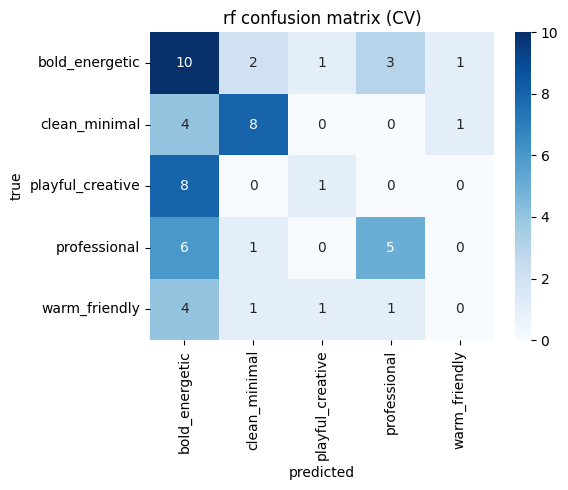

In [11]:
y_pred = cross_val_predict(models[best_name], X_sup, y, cv=skf)
print(classification_report(y, y_pred, zero_division=0))
labels_sorted = sorted(set(y))
cm = confusion_matrix(y, y_pred, labels=labels_sorted)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels_sorted, yticklabels=labels_sorted, ax=ax, cmap='Blues')
ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title(f'{best_name} confusion matrix (CV)')
fig.tight_layout(); fig.savefig(FIGS / 'classifier-cm.png', dpi=120); plt.show()

In [12]:
feat_names = CONT_VARS + ORD_VARS + BOOL_VARS
if best_name == 'rf':
    rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_sup, y)
    imp = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False)
    print('Random forest feature importances:'); print(imp.round(3).to_string())
else:
    lr = LogisticRegression(max_iter=1000).fit(X_sup, y)
    coef_abs = np.abs(lr.coef_).mean(axis=0)
    imp = pd.Series(coef_abs, index=feat_names).sort_values(ascending=False)
    print('Logistic regression mean |coef| per feature:'); print(imp.round(3).to_string())

Random forest feature importances:
body_line_height          0.124
btn_radius                0.104
brand_l                   0.088
brand_h                   0.087
accent_offset             0.084
heading_weight            0.083
brand_c                   0.079
btn_shape                 0.071
heading_letter_spacing    0.071
shadow_intensity          0.069
gray_chroma               0.067
card_radius               0.050
dark_mode_present         0.021
is_fully_pill             0.001


In [13]:
best_unsup_sil = max(gower_best_sil, gmm_best_sil)
best_unsup_method = 'gower' if gower_best_sil >= gmm_best_sil else 'gmm'
best_unsup_k = gower_best_k if best_unsup_method=='gower' else gmm_best_k
print(f'Best unsupervised: {best_unsup_method} k={best_unsup_k} sil={best_unsup_sil:.3f}')
print(f'Best supervised macro-F1: {best_macro_f1:.3f} ({best_name})')

# Hybrid: within-mood unsupervised silhouette
hybrid_pass = 0; hybrid_total = 0
for mood, sub in df.dropna(subset=['mood']).groupby('mood'):
    if len(sub) < 6: continue
    hybrid_total += 1
    sub_mixed = sub[CONT_VARS + ORD_VARS + BOOL_VARS].copy()
    for v in CONT_VARS:
        sub_mixed[v] = sub_mixed[v].astype(float).fillna(sub_mixed[v].median() if sub_mixed[v].notna().any() else 0)
    for v in ORD_VARS + BOOL_VARS:
        m = sub_mixed[v].mode().iloc[0] if not sub_mixed[v].mode().empty else 0
        sub_mixed[v] = sub_mixed[v].astype(float).fillna(m)
    cat_mask_sub = np.array([False]*len(CONT_VARS) + [True]*len(ORD_VARS) + [True]*len(BOOL_VARS))
    g = gower.gower_matrix(sub_mixed.to_numpy(dtype=float), cat_features=cat_mask_sub)
    if np.isnan(g).any():
        print(f'  mood={mood} n={len(sub)} skipped (NaN distance)')
        continue
    Zsub = linkage(squareform(g, checks=False), method='average')
    sub_sils = []
    for k in (2, 3):
        if k >= len(sub): continue
        labels = fcluster(Zsub, t=k, criterion='maxclust')
        if len(set(labels)) < 2: continue
        sub_sils.append(silhouette_score(g, labels, metric='precomputed'))
    best_sub = max(sub_sils) if sub_sils else -1.0
    if best_sub >= 0.30: hybrid_pass += 1
    print(f'  mood={mood} n={len(sub)} within-silhouette={best_sub:.3f}')
print(f'\nHybrid moods passing 0.30 threshold: {hybrid_pass}/{hybrid_total}')

rule_unsup = best_unsup_sil >= 0.30
rule_sup = best_macro_f1 >= 0.70 and best_unsup_sil < 0.30
rule_hybrid = best_macro_f1 >= 0.70 and hybrid_pass >= 3
print()
print(f'Rule 1 (continue unsupervised, sil>=0.30): {rule_unsup}')
print(f'Rule 2 (switch supervised, macro-F1>=0.70 & sil<0.30): {rule_sup}')
print(f'Rule 3 (hybrid, macro-F1>=0.70 & hybrid_pass>=3): {rule_hybrid}')
if rule_unsup: verdict = 'continue_unsupervised'
elif rule_hybrid: verdict = 'hybrid'
elif rule_sup: verdict = 'switch_supervised'
else: verdict = 'insufficient_signal'
print(f'\nVerdict: {verdict}')

Best unsupervised: gower k=5 sil=0.164
Best supervised macro-F1: 0.327 (rf)
  mood=bold_energetic n=17 within-silhouette=0.190
  mood=clean_minimal n=13 within-silhouette=0.246
  mood=playful_creative n=9 within-silhouette=0.258
  mood=professional n=12 within-silhouette=0.263
  mood=warm_friendly n=7 within-silhouette=0.193

Hybrid moods passing 0.30 threshold: 0/5

Rule 1 (continue unsupervised, sil>=0.30): False
Rule 2 (switch supervised, macro-F1>=0.70 & sil<0.30): False
Rule 3 (hybrid, macro-F1>=0.70 & hybrid_pass>=3): False

Verdict: insufficient_signal
